---

# Data distribution

>This notebook contains code for analysing the distribution of the corpus.
>The number of samples from countries is saved to `distribution.csv`

---

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import reverse_geocoder as rg
import pycountry
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid", font_scale=1.1)
pio.templates["custom"] = pio.templates["plotly_white"]
pio.templates.default = "custom"

## Load dataset

In [30]:
df = pd.read_csv(os.path.join('..', '.cache', 'mappings.csv'))
df = df[['lat', 'long']]

In [31]:
df['lat'] = df['lat'] * 90.0
df['long'] = df['long'] * 180.0

In [32]:
df.head()

,lat,long
0,33.568247,-203.813853
1,41.201394,18.674698
2,41.201394,18.674698
3,41.201394,18.674698
4,52.480925,-4.191456


## Scatter plot of latitudes and longitudes contained in the corpus

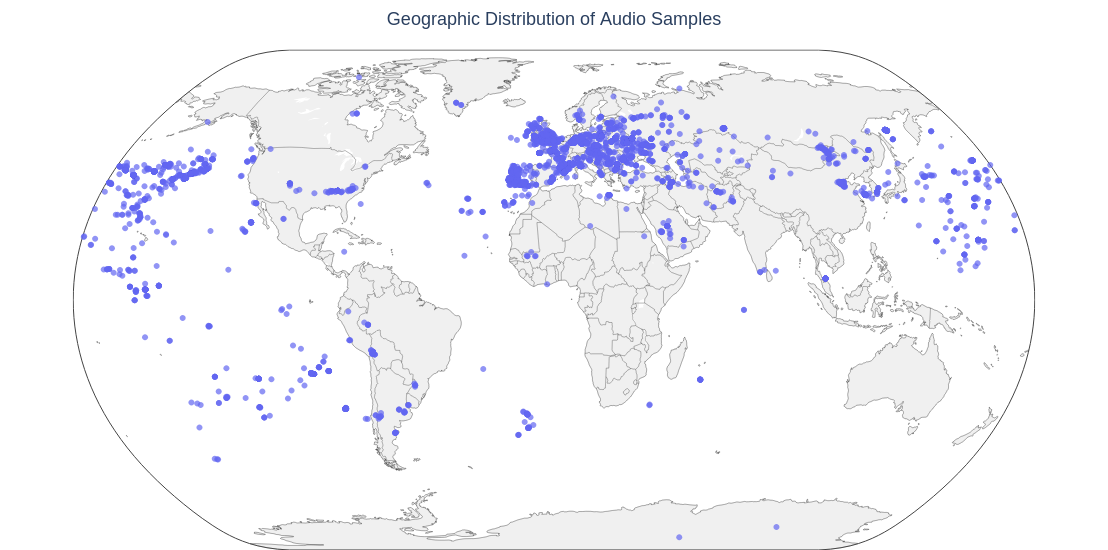

In [33]:
fig = px.scatter_geo(
    df, lat='lat', lon='long',
    title='Geographic Distribution of Audio Samples',
    opacity=0.7,
    color_discrete_sequence=['#6366f1'],
)
fig.update_geos(
    showcountries=True, countrycolor='rgba(0,0,0,0.15)',
    showcoastlines=True, coastlinecolor='rgba(0,0,0,0.2)',
    showland=True, landcolor='#f0f0f0',
    projection_type='natural earth',
    bgcolor='white',
)
fig.update_layout(
    title_x=0.5, title_font_size=18,
    margin=dict(l=0, r=0, t=50, b=0),
    height=550,
)
fig.show()

## Counts of samples from different countries

### Obtain country names from geotag

In [34]:
countries = list()

for i, row in tqdm(df.iterrows(), total=len(df), desc="Fetching countries"):
    location = rg.search([row['lat'], row['long']])
    cc = location[0].get('cc')

    country = pycountry.countries.get(alpha_2=cc).name

    countries.append(country)

Fetching countries:   0%|          | 0/5000 [00:00<?, ?it/s]

### Chloropleth plot

In [35]:
country_counts = pd.Series(countries).value_counts().reset_index()
country_counts.columns = ['country', 'count']
country_counts['iso_alpha'] = country_counts['country'].apply(lambda c: pycountry.countries.get(name=c).alpha_3)
country_counts.head()

,country,count,iso_alpha
0,Spain,1256,ESP
1,Russian Federation,621,RUS
2,United States,558,USA
3,France,324,FRA
4,Germany,272,DEU


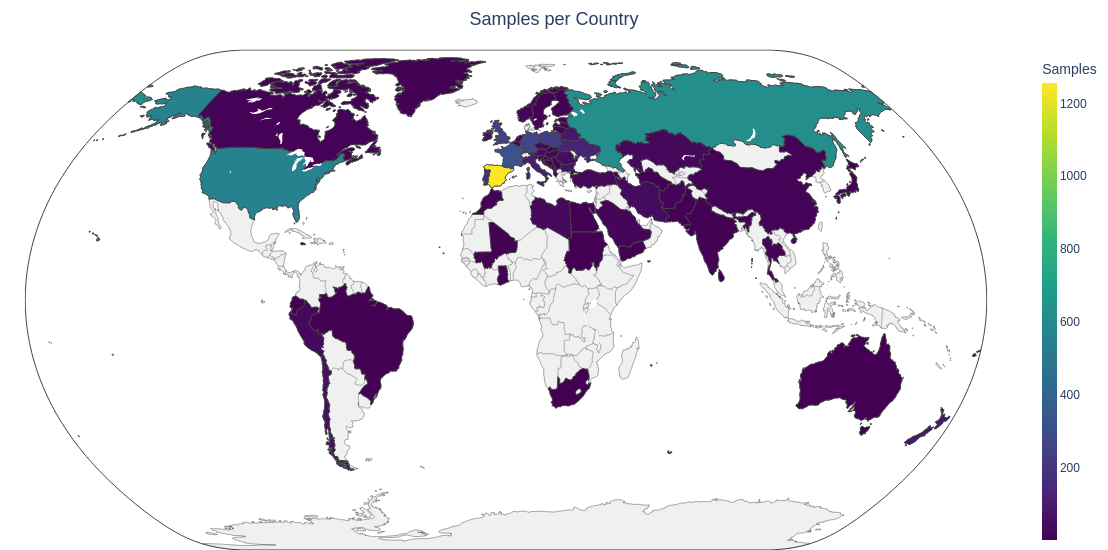

In [36]:
fig = px.choropleth(
    country_counts, locations='iso_alpha', locationmode='ISO-3',
    color='count', title='Samples per Country',
    hover_name='country',
    color_continuous_scale='Viridis',
    labels={'count': 'Number of Samples'},
)
fig.update_traces(text=country_counts['count'], hovertemplate='%{hovertext}<br>Samples: %{text}<extra></extra>')
fig.update_geos(
    showcountries=True, countrycolor='rgba(0,0,0,0.15)',
    showcoastlines=True, coastlinecolor='rgba(0,0,0,0.2)',
    showland=True, landcolor='#f0f0f0',
    projection_type='natural earth',
    bgcolor='white',
)
fig.update_layout(
    title_x=0.5, title_font_size=18,
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title='Samples', thickness=15),
    height=550,
)
fig.show()